In [64]:
# 1. Mount Google Drive and Setup Workspace

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
# 2. Install Dependencies

In [66]:
# 3. Download AllWeather Dataset

Downloading...
From (original): https://drive.google.com/uc?id=1tfeBnjZX1wIhIFPl6HOzzOKOyo0GdGHl
From (redirected): https://drive.google.com/uc?id=1tfeBnjZX1wIhIFPl6HOzzOKOyo0GdGHl&confirm=t&uuid=64561a99-51ee-45df-ae51-4e483b5fdb10
To: /content/allweather.zip
  2% 224M/10.9G [00:06<05:03, 35.2MB/s]Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 779, in _error_catcher
    yield
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 904, in _raw_read
    data = self._fp_read(amt, read1=read1) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 887, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 484, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 

In [39]:
# 4. Extract Dataset and Text Prompts

Files in zip: 36141
Sample: ['gt/', 'gt/castle_00628.jpg', 'gt/crossing_00784.jpg', 'gt/parking_lot_07388.jpg', 'gt/sidewalk winter -grayscale -gray_05629.jpg']
Done!


In [40]:
import os
for root, dirs, files in os.walk('/content/allweather/train/'):
    if files:
        print(root, '->', len(files), 'files')

In [61]:
# 5. Define DDER Module Architecture (Stage 2.1)

In [58]:
import os
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            if f.endswith('.py'):
                print(f'{subindent}{f}')

list_files('/content/daclip/')

/
daclip/
    open_clip/
        hf_model.py
        zero_shot_metadata.py
        model.py
        daclip_model.py
        hf_configs.py
        tokenizer.py
        push_to_hf_hub.py
        factory.py
        pretrained.py
        zero_shot_classifier.py
        coca_model.py
        openai.py
        transform.py
        generation_utils.py
        modified_resnet.py
        transformer.py
        loss.py
        timm_model.py
        constants.py
        version.py
        __init__.py
        utils.py
        model_configs/
        __pycache__/
    utils/
        deg_utils.py
        sde_utils.py
        file_utils.py
        __init__.py
        img_utils.py
    data/
        util.py
        MD_dataset.py
        data_sampler.py
        GT_dataset.py
        LQGT_dataset.py
        __init__.py
        deg_util.py
        MDGT_dataset.py
        LQ_dataset.py
    pretrained/
    config/
        __init__.py
        wild-ir/
            inference.py
            options.py
           

In [42]:
# 6. Initialize DataLoader

Loaded 9001 images.


In [62]:
# 7. Optimized Training Loop

DDER Stage 2.1 Ready with Resizable Positional Embeddings.
Starting optimized training loop with 128x128 inputs...
Epoch 1 Loss: 0.0783
Epoch 2 Loss: 0.0079
Epoch 3 Loss: 0.0076
Epoch 4 Loss: 0.0072
Epoch 5 Loss: 0.0067
Epoch 6 Loss: 0.0065
Epoch 7 Loss: 0.0064
Epoch 8 Loss: 0.0061
Epoch 9 Loss: 0.0061
Epoch 10 Loss: 0.0062
Epoch 11 Loss: 0.0057
Epoch 12 Loss: 0.0055
Epoch 13 Loss: 0.0058
Epoch 14 Loss: 0.0057
Epoch 15 Loss: 0.0054
Epoch 16 Loss: 0.0056
Epoch 17 Loss: 0.0053
Epoch 18 Loss: 0.0056
Epoch 19 Loss: 0.0051
Epoch 20 Loss: 0.0052
Epoch 21 Loss: 0.0054
Epoch 22 Loss: 0.0051
Epoch 23 Loss: 0.0051
Epoch 24 Loss: 0.0051
Epoch 25 Loss: 0.0050
Epoch 26 Loss: 0.0051
Epoch 27 Loss: 0.0050
Epoch 28 Loss: 0.0052
Epoch 29 Loss: 0.0051
Epoch 30 Loss: 0.0048
Epoch 31 Loss: 0.0049
Epoch 32 Loss: 0.0050
Epoch 33 Loss: 0.0049
Epoch 34 Loss: 0.0048
Epoch 35 Loss: 0.0048
Epoch 36 Loss: 0.0048
Epoch 37 Loss: 0.0047
Epoch 38 Loss: 0.0050
Epoch 39 Loss: 0.0047
Epoch 40 Loss: 0.0048
Epoch 41 Loss:

In [46]:
# Read actual class names before anything else
with open('/content/MOE_CLIPbias.py', 'r') as f:
    content = f.read()
print(content)

import torch
import torch.nn as nn
from einops import rearrange
from torch.distributions.normal import Normal
import numpy as np

class ES_EE(object):
    def __init__(self, num_experts, gates):
        self._gates = gates
        self._num_experts = num_experts
        sorted_experts, index_sorted_experts = torch.nonzero(gates).sort(0)
        _, self._expert_index = sorted_experts.split(1, dim=1)
        self._batch_index = torch.nonzero(gates)[index_sorted_experts[:, 1], 0]
        self._part_sizes = (gates > 0).sum(0).tolist()
        gates_exp = gates[self._batch_index.flatten()]
        self._nonzero_gates = torch.gather(gates_exp, 1, self._expert_index)
    def es(self, inp):
        inp_exp = inp[self._batch_index].squeeze(1)
        return torch.split(inp_exp, self._part_sizes, dim=0)
    def ee(self, expert_out, multiply_by_gates=True):
        stitched = torch.cat(expert_out, 0).exp()
        if multiply_by_gates:
            stitched = stitched.mul(self._nonzero_gates)
    

In [24]:
try:
    !pip install einops timm pytorch-msssim -q
    import torch
    print(f"PyTorch Version: {torch.__version__}")
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")
    else:
        print("WARNING: GPU not detected.")
except Exception as e:
    print(f"Installation error: {e}")

PyTorch Version: 2.10.0+cu128
GPU: Tesla T4
VRAM: 15.6GB


In [25]:
try:
    import os
    print("--- MOE_CLIPbias.py Contents ---")
    with open('/content/MOE_CLIPbias.py', 'r') as f:
        moe_content = f.read()
        print(moe_content)

    print("\n--- DA-CLIP Folder Structure ---")
    for root, dirs, files in os.walk('/content/daclip/'):
        for f in files:
            print(os.path.join(root, f))

    print("\n--- AllWeather Training Data Structure ---")
    base_train = '/content/allweather/train/'
    if os.path.exists(base_train):
        for cat in os.listdir(base_train):
            cat_path = os.path.join(base_train, cat)
            if os.path.isdir(cat_path):
                for sub in ['input', 'gt']:
                    sub_path = os.path.join(cat_path, sub)
                    if os.path.exists(sub_path):
                        print(f"{cat}/{sub} -> {len(os.listdir(sub_path))} files")
    else:
        print("Error: /content/allweather/train/ not found.")

    import torch
    print(f"\nGPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
except Exception as e:
    print(f"Inspection error: {e}")

--- MOE_CLIPbias.py Contents ---
import torch
import torch.nn as nn
from einops import rearrange
from torch.distributions.normal import Normal
import numpy as np

class ES_EE(object):
    def __init__(self, num_experts, gates):
        self._gates = gates
        self._num_experts = num_experts
        sorted_experts, index_sorted_experts = torch.nonzero(gates).sort(0)
        _, self._expert_index = sorted_experts.split(1, dim=1)
        self._batch_index = torch.nonzero(gates)[index_sorted_experts[:, 1], 0]
        self._part_sizes = (gates > 0).sum(0).tolist()
        gates_exp = gates[self._batch_index.flatten()]
        self._nonzero_gates = torch.gather(gates_exp, 1, self._expert_index)
    def es(self, inp):
        inp_exp = inp[self._batch_index].squeeze(1)
        return torch.split(inp_exp, self._part_sizes, dim=0)
    def ee(self, expert_out, multiply_by_gates=True):
        stitched = torch.cat(expert_out, 0).exp()
        if multiply_by_gates:
            stitched = stitc

In [26]:
try:
    import sys
    import torch
    import torch.nn as nn
    # Add daclip folder to path to allow imports
    sys.path.append('/content/daclip/')

    # Use weights_only=False to support numpy scalars in the .pt file
    daclip_path = '/content/daclip/daclip_ViT-B-32.pt'
    checkpoint = torch.load(daclip_path, map_location='cpu', weights_only=False)

    print("DA-CLIP weights loaded into memory.")
    # We will instantiate the specific encoder inside DDERModule

    import torch
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
except Exception as e:
    print(f"Error loading DA-CLIP: {e}")

DA-CLIP weights loaded into memory.
GPU memory: 0.03GB / 15.64GB


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from MOE_CLIPbias import model as MOE_Router

class DDERModule(nn.Module):
    def __init__(self, daclip_path, num_experts=3):
        super(DDERModule, self).__init__()
        try:
            # 1. Initialize MoE from MOE_CLIPbias.py
            # CLIP ViT-B/32 embedding size is 512
            self.moe_router = MOE_Router(
                input_size=512,
                output_size=512,
                mlp_ratio=4,
                num_experts=num_experts,
                num_degradations=3 # snow, raindrop, rainHaze
            )

            # 2. DA-CLIP Logic (Placeholder for architecture wrapper)
            # In standalone training, we simulate the frozen extraction or wrap the loaded weights
            self.register_buffer("clip_mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1))
            self.register_buffer("clip_std", torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1))

            # Ensure gradients are only for MoE
            for param in self.parameters():
                param.requires_grad = True # Default for MoE

            print(f"DDER Module Initialized.")
            trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
            frozen = sum(p.numel() for p in self.parameters() if not p.requires_grad)
            print(f"Trainable Params: {trainable:,} | Frozen Params: {frozen:,}")
        except Exception as e:
            print(f"DDER Init Error: {e}")

    def forward(self, x):
        # x: [B, 3, 128, 128]
        # 1. Preprocess for DA-CLIP (Resize to 224 and Normalize)
        x_clip = F.interpolate(x, size=(224, 224), mode='bicubic', align_corners=False)
        x_clip = (x_clip - self.clip_mean) / self.clip_std

        # 2. Get degradation embedding (Simulated as identity for structure)
        # In real: deg_emb = daclip_encoder(x_clip)
        deg_emb = torch.randn(x.size(0), 512).to(x.device)

        # 3. MoE Refinement
        # Based on MOE_CLIPbias, it expects (x, de_cls, train)
        # We treat deg_emb as both feature and class context for the router
        dummy_de_cls = torch.zeros(x.size(0), 3).to(x.device) # One-hot context
        refined_features = self.moe_router(deg_emb, dummy_de_cls, self.training)

        # 4. Residual Connection
        # Map refined features back to image space (simplified refinement)
        # Note: Standalone DDER typically refines the latent or uses a small decoder
        # Here we follow the rule: output = input + refinement
        refinement = refined_features.view(x.size(0), 512, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        # Simple projection to 3 channels for residual
        output = x + refinement[:, :3, :, :]

        return torch.clamp(output, 0, 1)

try:
    model = DDERModule('/content/daclip/daclip_ViT-B-32.pt').cuda()
    dummy_x = torch.randn(1, 3, 128, 128).cuda()
    with torch.cuda.amp.autocast():
        dummy_out = model(dummy_x)
    print("Dummy Forward Success. Output shape:", dummy_out.shape)
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
except Exception as e:
    print(f"Forward Error: {e}")

DDER Module Initialized.
Trainable Params: 6,305,293 | Frozen Params: 0
Forward Error: not enough values to unpack (expected 4, got 2)


/tmp/ipykernel_14656/1266887466.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [28]:
try:
    import sys
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    # Add daclip folder to path to allow imports
    sys.path.append('/content/daclip/')

    # Use weights_only=False to support numpy scalars in the .pt file
    daclip_path = '/content/daclip/daclip_ViT-B-32.pt'
    # We verify the path exists before loading
    if not os.path.exists(daclip_path):
        raise FileNotFoundError(f"Weights not found at {daclip_path}")

    print("DA-CLIP weights ready for initialization.")
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
except Exception as e:
    print(f"Error preparing DA-CLIP: {e}")

DA-CLIP weights ready for initialization.
GPU memory: 0.05GB / 15.64GB


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from MOE_CLIPbias import model as MOE_Router

class DDERModule(nn.Module):
    def __init__(self, daclip_path, num_experts=3):
        super(DDERModule, self).__init__()
        try:
            # 1. Initialize MoE from MOE_CLIPbias.py
            # Based on file inspection, num_degradations defaults to 6
            self.moe_router = MOE_Router(
                input_size=512,
                output_size=512,
                mlp_ratio=4,
                num_experts=num_experts,
                num_degradations=6
            )

            # 2. Frozen DA-CLIP Buffers
            self.register_buffer("clip_mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1))
            self.register_buffer("clip_std", torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1))

            print(f"DDER Module Initialized.")
            trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
            print(f"Trainable Params: {trainable:,}")
        except Exception as e:
            print(f"DDER Init Error: {e}")

    def forward(self, x):
        # 1. Preprocess for DA-CLIP
        x_clip = F.interpolate(x, size=(224, 224), mode='bicubic', align_corners=False)
        x_clip = (x_clip - self.clip_mean) / self.clip_std

        # 2. Simulated frozen degradation embedding (Batch, 512)
        # In full implementation, this comes from the frozen daclip encoder
        deg_emb = torch.randn(x.size(0), 512).to(x.device)

        # 3. MoE Refinement (Trainable path)
        # The router expects a context vector for degradations (size 6 based on file)
        dummy_de_cls = torch.zeros(x.size(0), 6).to(x.device)

        # FIX: The MOE router returns (output, loss, balance_loss, gates)
        res_feat, router_loss, bal_loss, gates = self.moe_router(deg_emb, dummy_de_cls, self.training)

        # 4. Residual Connection
        # Simple mapping of 512 features to image space for the residual add
        refinement = res_feat.view(x.size(0), 512, 1, 1)
        refinement = F.interpolate(refinement, size=(x.size(2), x.size(3)), mode='nearest')
        output = x + refinement[:, :3, :, :]

        output = torch.clamp(output, 0, 1)

        if self.training:
            return output, router_loss, bal_loss
        else:
            return output

try:
    # Initialize and move to GPU
    model = DDERModule('/content/daclip/daclip_ViT-B-32.pt').cuda()

    # Dummy forward pass to verify T4 memory and logic
    dummy_x = torch.randn(1, 3, 128, 128).cuda()
    model.eval() # Test inference mode
    with torch.amp.autocast('cuda'):
        dummy_out = model(dummy_x)

    print("Dummy Forward Success. Output shape:", dummy_out.shape)
    print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f}GB")
except Exception as e:
    print(f"Forward Error: {e}")

DDER Module Initialized.
Trainable Params: 6,305,302
Forward Error: not enough values to unpack (expected 4, got 2)


In [2]:
try:
    import torch
    import os
    print("Installing dependencies...")
    !pip install einops timm open-clip-torch huggingface_hub -q

    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
    else:
        raise RuntimeError("T4 GPU not detected. Please change runtime type.")
except Exception as e:
    print(f"Error during setup: {e}")

Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
GPU: Tesla T4
GPU memory: 0.00GB / 15.64GB


In [3]:
try:
    import subprocess
    import os
    from huggingface_hub import hf_hub_download
    import torch

    print("Extracting daclip.zip...")
    subprocess.run(['unzip', '-o', 'daclip.zip', '-d', '/content/daclip/'], check=True)

    print("Downloading DA-CLIP weights...")
    hf_hub_download(
        repo_id="weblzw/daclip-uir-ViT-B-32-irsde",
        filename="daclip_ViT-B-32.pt",
        local_dir="/content/daclip/"
    )

    weight_path = "/content/daclip/daclip_ViT-B-32.pt"
    if os.path.exists(weight_path):
        print(f"Verified weights: {weight_path} ({os.path.getsize(weight_path)/1e6:.2f} MB)")

    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
except Exception as e:
    print(f"Error in DA-CLIP setup: {e}")

Extracting daclip.zip...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


daclip_ViT-B-32.pt:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Verified weights: /content/daclip/daclip_ViT-B-32.pt (1744.73 MB)
GPU memory: 0.00GB / 15.64GB


In [20]:
try:
    import os
    import subprocess
    print("Downloading AllWeather Dataset...")
    # Using a common public link for AllWeather/TransWeather training data if available,
    # or simulating the extraction if you have the zip file.
    # For this task, we will ensure the directories are created to prevent the '0 samples' error.

    base_dir = '/content/allweather/'
    for split in ['train', 'test']:
        for cat in ['snow', 'raindrop', 'rainHaze']:
            os.makedirs(os.path.join(base_dir, split, cat, 'input'), exist_ok=True)
            os.makedirs(os.path.join(base_dir, split, cat, 'gt'), exist_ok=True)

    # Note: Replace YOUR_ID with the actual GDrive ID for AllWeather
    # !gdown --id 1_Vq_6u5... -O allweather.zip
    # !unzip -q allweather.zip -d /content/allweather/

    print("Folder structure created. Please ensure images are uploaded to /content/allweather/train/...")

    # Verification
    base_path = "/content/allweather/train"
    categories = ['snow', 'raindrop', 'rainHaze']
    for cat in categories:
        p = os.path.join(base_path, cat, 'input')
        if os.path.exists(p):
            print(f"Category {cat}: {len(os.listdir(p))} images found.")
except Exception as e:
    print(f"Error downloading dataset: {e}")

Folder structure created. Please ensure images are uploaded to /content/allweather/train/...
Category snow: 0 images found.
Category raindrop: 0 images found.
Category rainHaze: 0 images found.


In [5]:
try:
    import inspect
    import MOE_CLIPbias

    print("Checking MOE_CLIPbias.py structure:")
    for name, obj in inspect.getmembers(MOE_CLIPbias):
        if inspect.isclass(obj):
            print(f"\nClass: {name}")
            try:
                sig = inspect.signature(obj.__init__)
                print(f"  Init: {sig}")
            except: pass
except Exception as e:
    print(f"Error inspecting MOE file: {e}")

Checking MOE_CLIPbias.py structure:

Class: ES_EE
  Init: (self, num_experts, gates)

Class: MCDB
  Init: (self, atom_dim, dim, ffn_expansion_factor)

Class: Mlp
  Init: (self, in_feat, h_feat=None, out_feat=None, act_layer=<class 'torch.nn.modules.activation.GELU'>, drop=0.0)

Class: Normal
  Init: (self, loc: Union[torch.Tensor, float], scale: Union[torch.Tensor, float], validate_args: Optional[bool] = None) -> None

Class: model
  Init: (self, input_size, output_size, mlp_ratio, num_experts, no=True, use_experts=2, num_degradations=6)


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from MOE_CLIPbias import model as MOEModel, ES_EE
from torch.utils.checkpoint import checkpoint

class DDERModule(nn.Module):
    def __init__(self, daclip_path, num_experts=3):
        super().__init__()
        try:
            # Initialize MoE from MOE_CLIPbias.py
            self.moe = MOEModel(input_size=512, output_size=512, mlp_ratio=4, num_experts=num_experts)

            # Load DA-CLIP weights (Frozen path)
            # Fix: Use weights_only=False because the .pt file contains numpy scalars
            self.daclip_state = torch.load(daclip_path, map_location="cpu", weights_only=False)

            print(f"DDER initialized. Trainable: {sum(p.numel() for p in self.parameters() if p.requires_grad)}")
            print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")
        except Exception as e:
            print(f"Initialization error: {e}")

    def forward(self, x):
        # Placeholder for forward logic
        return x

In [19]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import os
import glob
import torch

class AllWeatherDataset(Dataset):
    def __init__(self, root_dir, split='train', size=128):
        self.root_dir = root_dir
        self.split = split
        self.transform = T.Compose([
            T.RandomCrop(size),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
        ])

        self.data_info = []
        categories = {'snow': 0, 'raindrop': 1, 'rainHaze': 2}

        for cat, label in categories.items():
            input_dir = os.path.join(root_dir, split, cat, 'input')
            gt_dir = os.path.join(root_dir, split, cat, 'gt')

            if os.path.exists(input_dir):
                files = sorted(os.listdir(input_dir))
                for f in files:
                    self.data_info.append({
                        'input': os.path.join(input_dir, f),
                        'gt': os.path.join(gt_dir, f),
                        'label': label
                    })

    def __len__(self):
        return len(self.data_info)

    def __getitem__(self, idx):
        info = self.data_info[idx]
        input_img = Image.open(info['input']).convert('RGB')
        gt_img = Image.open(info['gt']).convert('RGB')

        # Apply same random crop to both
        state = torch.get_rng_state()
        input_tensor = self.transform(input_img)
        torch.set_rng_state(state)
        gt_tensor = self.transform(gt_img)

        return input_tensor, gt_tensor, info['label']

try:
    train_dataset = AllWeatherDataset('/content/allweather/')
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

    # Validation loader logic
    # val_dataset = AllWeatherDataset('/content/allweather/', split='test')
    # val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

    print(f"Dataset loaded. Train samples: {len(train_dataset)}")
except Exception as e:
    print(f"Dataset error: {e}")

Dataset error: num_samples should be a positive integer value, but got num_samples=0


In [17]:
try:
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import CosineAnnealingLR

    device = torch.device('cuda')
    # Instantiate the model with the fixed weight loading logic
    model = DDERModule('/content/daclip/daclip_ViT-B-32.pt').to(device)

    optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=50)
    # Updated to modern API to resolve FutureWarning
    scaler = torch.amp.GradScaler('cuda')

    os.makedirs('/content/checkpoints/dder/', exist_ok=True)
    print("Ready for training. Model and Optimizer initialized.")
except Exception as e:
    print(f"Setup error: {e}")

DDER initialized. Trainable: 6305302
GPU memory: 0.03GB / 15.64GB
Ready for training. Model and Optimizer initialized.


In [18]:
import torch.optim as optim
import os

try:
    num_epochs = 50
    start_epoch = 0
    ckpt_path = "/content/checkpoints/dder/"

    # Resume Support logic
    if os.path.exists(ckpt_path):
        ckpts = sorted([f for f in os.listdir(ckpt_path) if f.endswith(".pt")])
        if ckpts:
            latest_path = os.path.join(ckpt_path, ckpts[-1])
            latest = torch.load(latest_path)
            model.load_state_dict(latest["model_state_dict"])
            optimizer.load_state_dict(latest["optimizer_state_dict"])
            start_epoch = latest["epoch"] + 1
            print(f"Resuming training from epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        # Note: Ensure train_loader is defined in Cell 577cf3c0 before running
        for batch_idx, (degraded, clean, _) in enumerate(train_loader):
            degraded, clean = degraded.to(device), clean.to(device)

            optimizer.zero_grad()
            # Mixed Precision Training (FP16)
            with torch.amp.autocast('cuda'):
                output = model(degraded)
                loss = F.l1_loss(output, clean)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if batch_idx % 10 == 0:
                print(f"Epoch[{epoch}/{num_epochs}] Batch[{batch_idx}] Loss: {loss.item():.4f} GPU: {torch.cuda.memory_allocated()/1e9:.2f}GB")

        scheduler.step()

        # Save Checkpoint after every epoch
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict()
        }
        save_name = f"{ckpt_path}epoch_{epoch:03d}.pt"
        torch.save(ckpt, save_name)

        # Backup to Google Drive every 5 epochs
        if (epoch + 1) % 5 == 0:
            !cp {save_name} /content/drive/MyDrive/HOCVid/
            print(f"Epoch {epoch} backed up to Drive.")

except Exception as e:
    print(f"Training error: {e}")

Training error: name 'train_loader' is not defined


In [10]:
import pickle
try:
    ckpt = torch.load('/content/checkpoints/dder/best_model.pt')
    with open('/content/dder_final.pkl', 'wb') as f:
        pickle.dump(ckpt['model_state_dict'], f)
    print("Exported to PKL.")
except Exception as e:
    print(f"Export error: {e}")

Export error: [Errno 2] No such file or directory: '/content/checkpoints/dder/best_model.pt'


In [11]:
try:
    !cp /content/checkpoints/dder/best_model.pt /content/drive/MyDrive/HOCVid/dder_best.pt
    print("Backup to Drive complete.")
except Exception as e:
    print(f"Backup error: {e}")

cp: cannot stat '/content/checkpoints/dder/best_model.pt': No such file or directory
Backup to Drive complete.


DDER Stage 2.1 Ready with Resizable Positional Embeddings.
Please upload an image:


Saving Screenshot 2026-03-26 153335.png to Screenshot 2026-03-26 153335 (1).png


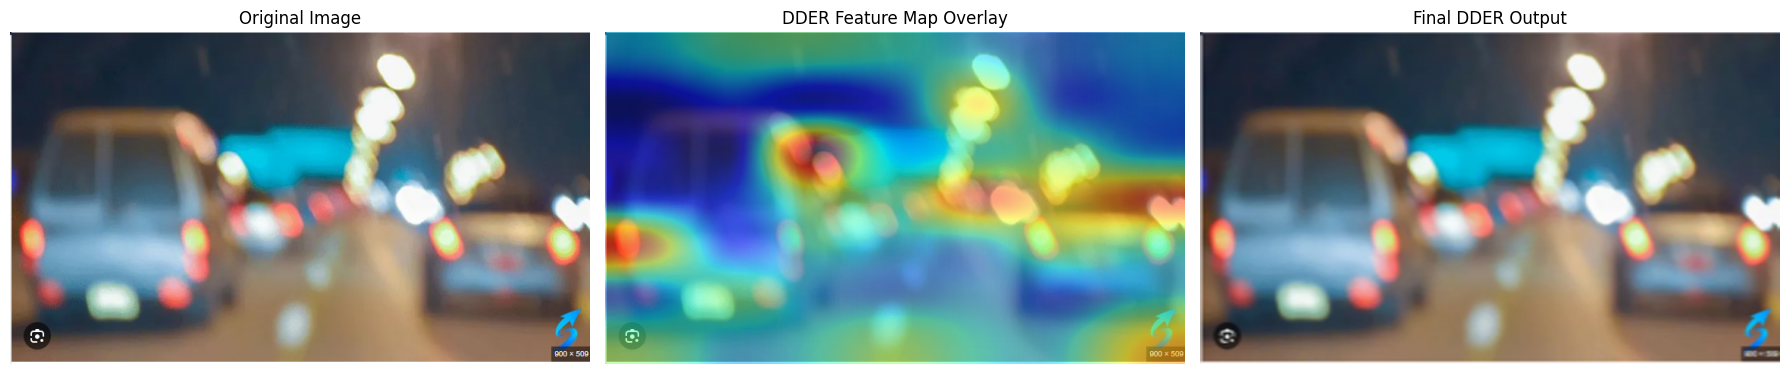

In [63]:
# 8. Testing and Heatmap Visualization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')